In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
df = pd.read_csv("/content/hotel_bookings 2.csv")

In [4]:
df.shape


(119390, 32)

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
df.describe()


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [9]:
missing = df.isnull().sum()

missing = missing[missing>0].sort_values(ascending=False)

missing


,0
company,112593
agent,16340
country,488
children,4


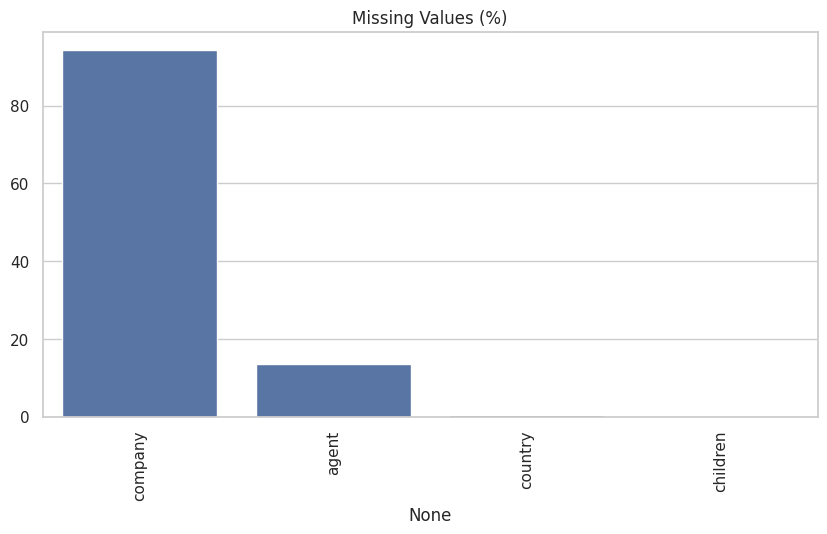

In [10]:
missing_percent = (missing / len(df)) * 100
#visualize the missing value
plt.figure(figsize=(10,5))

sns.barplot(x=missing_percent.index, y=missing_percent.values)

plt.xticks(rotation=90)

plt.title("Missing Values (%)")

plt.show()

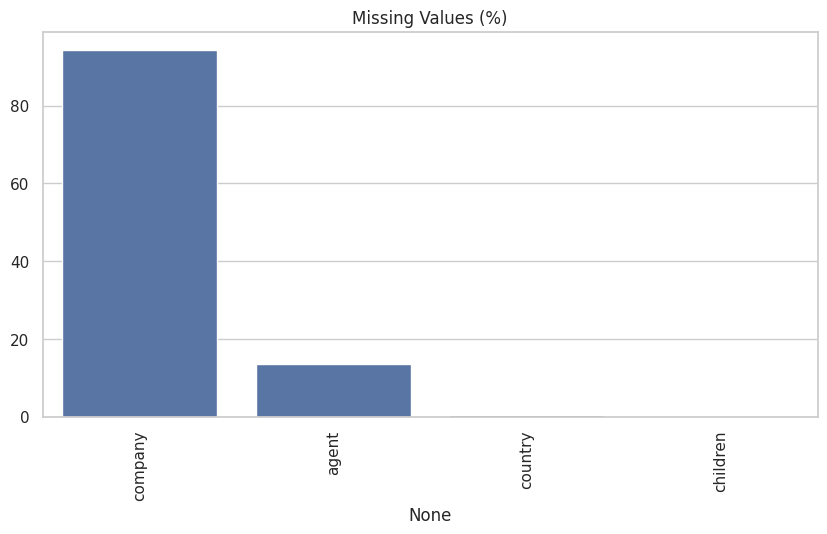

In [11]:
missing_percent = (missing / len(df)) * 100
# visualization of missing values
plt.figure(figsize=(10,5))

sns.barplot(x=missing_percent.index,
            y=missing_percent.values)

plt.xticks(rotation=90)

plt.title("Missing Values (%)")

plt.show()

In [12]:
# handling of missing values


In [13]:
df.drop(columns='company', inplace=True)


In [14]:
df['agent'] = df['agent'].fillna(0)


In [15]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [16]:
df['children'] = df['children'].fillna(df['children'].median())

In [17]:
df.isnull().sum()


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [18]:
# rove duplicate data
df.duplicated().sum()


np.int64(32020)

In [19]:
df.drop_duplicates(inplace=True)


In [20]:
df.duplicated().sum()


np.int64(0)

In [21]:
df.reset_index(drop=True, inplace=True)

In [22]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [23]:
#covert data types

In [24]:
df['agent'] = df['agent'].astype(int)

df['children'] = df['children'].astype(int)


In [25]:
# invalid booking datas
df[(df['adults']==0) &
   (df['children']==0) &
   (df['babies']==0)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2088,Resort Hotel,0,1,2015,October,41,6,0,3,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2224,Resort Hotel,0,0,2015,October,42,12,0,0,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0,0,Transient,0.00,0,0,Check-Out,2015-10-12
2804,Resort Hotel,0,36,2015,November,47,20,1,2,0,0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3091,Resort Hotel,0,165,2015,December,53,30,1,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3099,Resort Hotel,0,165,2015,December,53,30,2,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83702,City Hotel,0,107,2017,June,26,27,0,3,0,0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,7,0,Transient,100.80,0,0,Check-Out,2017-06-30
83754,City Hotel,0,1,2017,June,26,30,0,1,0,0,0,SC,PRT,Complementary,Direct,0,0,0,E,K,0,No Deposit,0,0,Transient,0.00,1,1,Check-Out,2017-07-01
84688,City Hotel,0,44,2017,July,28,15,1,1,0,0,0,SC,SWE,Online TA,TA/TO,0,0,0,A,K,2,No Deposit,425,0,Transient,73.80,0,0,Check-Out,2017-07-17
84944,City Hotel,0,2,2017,July,28,15,2,5,0,0,0,SC,RUS,Online TA,TA/TO,0,0,0,A,K,1,No Deposit,9,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22


In [26]:
# remove invalid data
df = df[~((df['adults']==0) &
          (df['children']==0) &
          (df['babies']==0))]

In [27]:
#average daily revenue check
df[df['adr']<0]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
11588,Resort Hotel,0,195,2017,March,10,5,4,6,2,0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [28]:
#remove negative adr
df = df[df['adr']>=0]

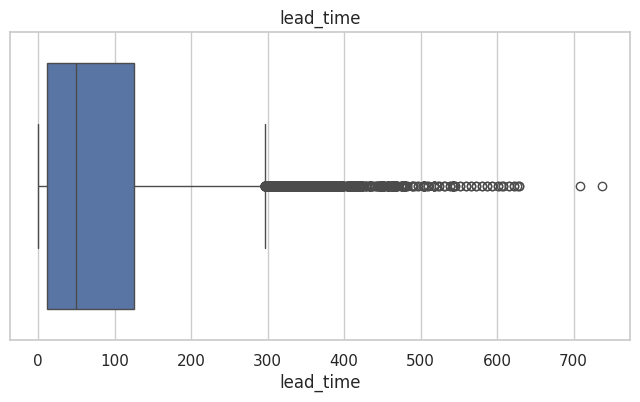

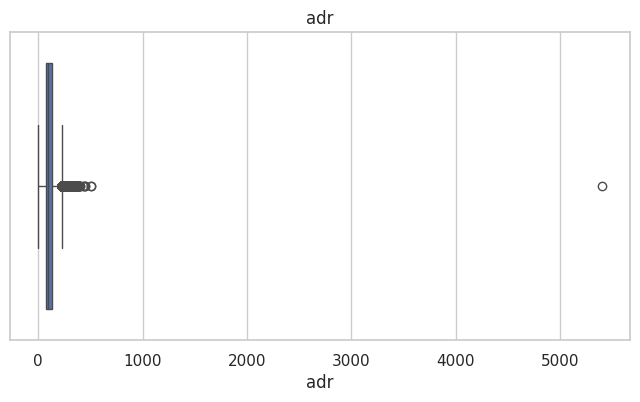

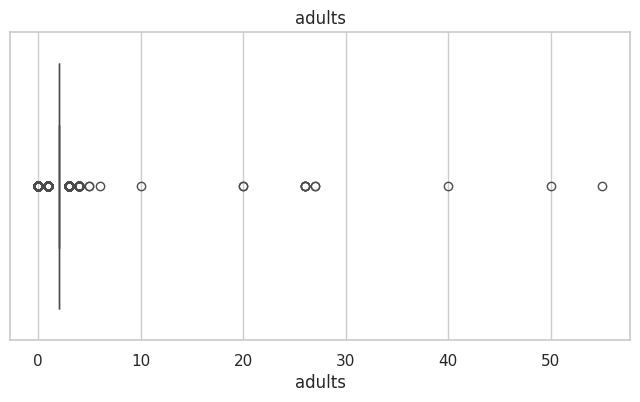

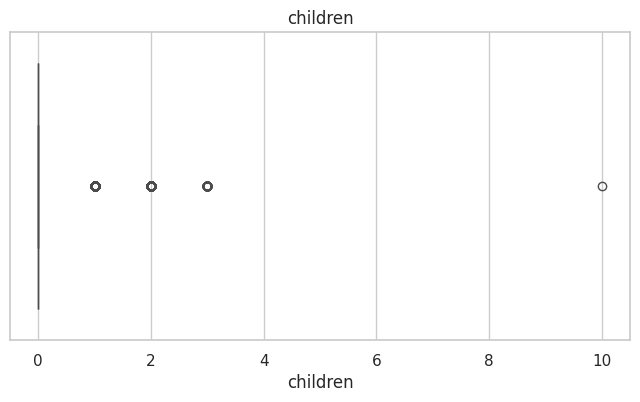

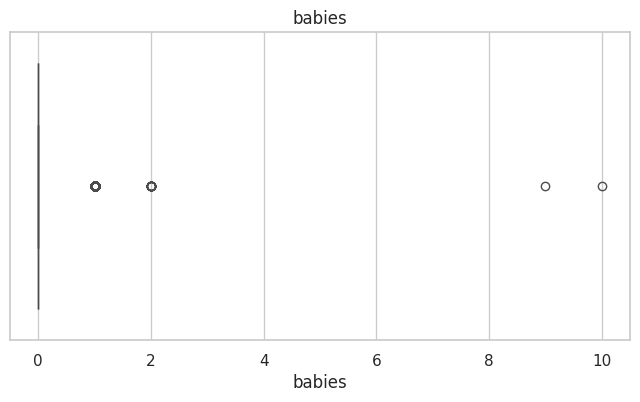

In [29]:
#check for outliers
cols = ['lead_time','adr','adults','children','babies']

for col in cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [30]:
#count for outliers
for col in cols:

    Q1=df[col].quantile(.25)

    Q3=df[col].quantile(.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    outliers=df[(df[col]<lower)|(df[col]>upper)]

    print(col,len(outliers))

lead_time 2394
adr 2506
adults 22716
children 8364
babies 914


In [31]:
df['adults'].describe()


,adults
count,87203.000000
mean,1.879522
std,0.621698
min,0.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,55.000000


In [32]:
df[df['adults'] > 25][['adults', 'children', 'babies']].head(20)

,adults,children,babies
1455,40,0,0
1503,26,0,0
1558,50,0,0
1664,26,0,0
1788,26,0,0
1816,27,0,0
1859,27,0,0
1897,26,0,0
2044,26,0,0
2053,55,0,0


In [33]:
df[df['adults'] > 25]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
1455,Resort Hotel,1,304,2015,September,36,3,0,3,40,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Group,0.0,0,0,Canceled,2015-01-02
1503,Resort Hotel,1,333,2015,September,36,5,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.0,0,0,Canceled,2015-01-02
1558,Resort Hotel,1,336,2015,September,37,7,1,2,50,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Group,0.0,0,0,Canceled,2015-01-18
1664,Resort Hotel,1,340,2015,September,37,12,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.0,0,0,Canceled,2015-01-02
1788,Resort Hotel,1,347,2015,September,38,19,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.0,0,0,Canceled,2015-01-02
1816,Resort Hotel,1,349,2015,September,39,21,1,3,27,0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Group,0.0,0,0,Canceled,2015-01-02
1859,Resort Hotel,1,352,2015,September,39,24,1,3,27,0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Group,0.0,0,0,Canceled,2015-01-02
1897,Resort Hotel,1,354,2015,September,39,26,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.0,0,0,Canceled,2015-01-02
2044,Resort Hotel,1,361,2015,October,40,3,2,5,26,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96,0,Group,0.0,0,0,Canceled,2015-01-02
2053,Resort Hotel,1,338,2015,October,41,4,2,0,55,0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Group,0.0,0,0,Canceled,2015-01-02


In [34]:
# Remove bookings where adults > 25
df = df[df['adults'] <= 25]

# Reset index
df.reset_index(drop=True, inplace=True)

In [35]:
print(df['adults'].max())
print(df['children'].max())
print(df['babies'].max())

20
10
10


In [36]:
df[df['adults'] > 25]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [37]:
df['adr'].describe()

,adr
count,87193.000000
mean,106.541304
std,54.871694
min,0.000000
25%,72.250000
50%,98.250000
75%,134.100000
max,5400.000000


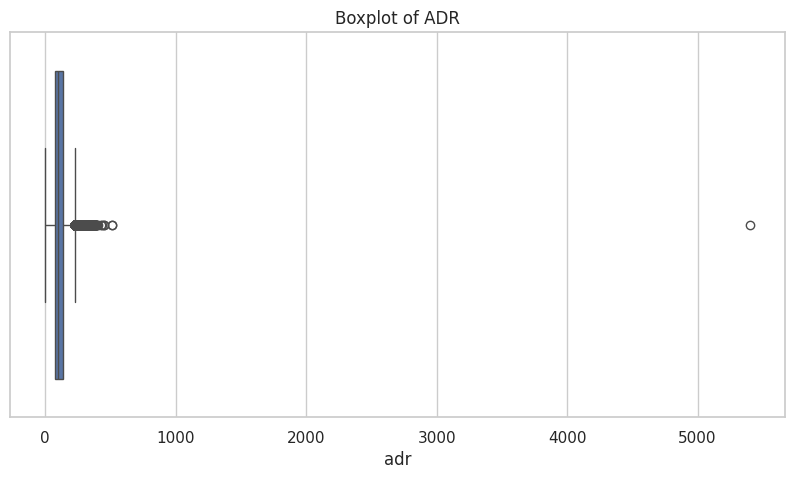

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x=df['adr'])
plt.title("Boxplot of ADR")
plt.show()

In [39]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

Lower Limit: -20.52499999999999
Upper Limit: 226.875


In [40]:
adr_outliers = df[df['adr'] > upper]

print("Number of ADR Outliers:", len(adr_outliers))

Number of ADR Outliers: 2506


In [41]:
adr_outliers[['hotel',
              'adr',
              'country',
              'reserved_room_type',
              'assigned_room_type',
              'market_segment',
              'customer_type',
              'adults',
              'children',
              'babies']].sort_values(by='adr', ascending=False)

,hotel,adr,country,reserved_room_type,assigned_room_type,market_segment,customer_type,adults,children,babies
38691,City Hotel,5400.00,PRT,A,A,Offline TA/TO,Transient,2,0,0
80541,City Hotel,510.00,ITA,A,G,Offline TA/TO,Transient,1,0,0
11640,Resort Hotel,508.00,PRT,A,C,Corporate,Transient,2,0,0
74308,City Hotel,451.50,PRT,E,E,Direct,Transient-Party,2,2,0
9966,Resort Hotel,450.00,PRT,A,A,Online TA,Transient,2,0,0
...,...,...,...,...,...,...,...,...,...,...
20494,Resort Hotel,227.00,PRT,G,G,Direct,Transient,2,2,0
41376,City Hotel,226.95,FIN,G,G,Direct,Transient,2,2,0
64621,City Hotel,226.95,NOR,G,G,Direct,Transient,2,3,0
68900,City Hotel,226.95,CHE,G,G,Direct,Transient,3,1,0


In [42]:
# remove adr 5400
df = df[df['adr'] != 5400]

df.reset_index(drop=True, inplace=True)

In [43]:
df[df['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [44]:
df[df['adr'] == 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
122,Resort Hotel,0,32,2015,July,27,4,0,1,4,0,0,FB,PRT,Complementary,Direct,0,0,0,H,H,2,No Deposit,0,0,Transient,0.0,0,1,Check-Out,2015-07-05
163,Resort Hotel,0,111,2015,July,28,6,0,0,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,H,0,No Deposit,240,0,Transient,0.0,0,2,Check-Out,2015-07-06
164,Resort Hotel,0,0,2015,July,28,6,0,0,1,0,0,BB,PRT,Direct,Direct,0,0,0,E,H,0,No Deposit,250,0,Transient,0.0,0,0,Check-Out,2015-07-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86608,City Hotel,0,78,2017,August,34,23,0,0,1,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,K,7,No Deposit,98,0,Transient-Party,0.0,0,0,Check-Out,2017-08-23
86727,City Hotel,0,1,2017,August,34,24,0,1,2,1,0,BB,PRT,Complementary,Direct,0,0,0,A,D,1,No Deposit,0,0,Transient,0.0,0,3,Check-Out,2017-08-25
86869,City Hotel,0,1,2017,August,35,27,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2017-08-27
86980,City Hotel,0,518,2017,August,34,26,2,1,1,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,229,0,Transient-Party,0.0,0,0,Check-Out,2017-08-29


In [45]:
#adr =0 is cancelled ?
df[df['adr'] == 0]['is_canceled'].value_counts()

,count
is_canceled,
0,1474
1,159


In [46]:
# add new coloum as total guest
df['total_guests']=df['adults']+df['children']+df['babies']

In [47]:
# add new coloum as total nights
df['total_nights']=df['stays_in_weekend_nights']+df['stays_in_week_nights']

In [48]:
#total revenue
df['revenue']=df['adr']*df['total_nights']

In [49]:
#arrival date
df['arrival_date']=pd.to_datetime(
df['arrival_date_year'].astype(str)+'-'+
df['arrival_date_month']+'-'+
df['arrival_date_day_of_month'].astype(str))

#booking month
df['booking_month']=df['arrival_date'].dt.month_name()

#booking quarter
df['quarter']=df['arrival_date'].dt.quarter

In [50]:
#classifiying seasons
def season(x):

    if x in [12,1,2]:
        return "Winter"

    elif x in [3,4,5]:
        return "Summer"

    elif x in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

df['season']=df['arrival_date'].dt.month.apply(season)

In [51]:
#family bookings
df['family_booking']=np.where(df['children']+df['babies']>0,"Yes","No")

#repeat guest
df['repeat_guest']=np.where(df['is_repeated_guest']==1,"Yes","No")

#cancelled bookings
df['booking_status']=np.where(df['is_canceled']==1,"Cancelled","Not Cancelled")

In [52]:
df[['total_guests',
    'total_nights',
    'revenue',
    'arrival_date',
    'booking_month',
    'quarter',
    'season',
    'family_booking',
    'repeat_guest',
    'booking_status']].head(10)

,total_guests,total_nights,revenue,arrival_date,booking_month,quarter,season,family_booking,repeat_guest,booking_status
0,2,0,0.0,2015-07-01,July,3,Monsoon,No,No,Not Cancelled
1,2,0,0.0,2015-07-01,July,3,Monsoon,No,No,Not Cancelled
2,1,1,75.0,2015-07-01,July,3,Monsoon,No,No,Not Cancelled
3,1,1,75.0,2015-07-01,July,3,Monsoon,No,No,Not Cancelled
4,2,2,196.0,2015-07-01,July,3,Monsoon,No,No,Not Cancelled
5,2,2,214.0,2015-07-01,July,3,Monsoon,No,No,Not Cancelled
6,2,2,206.0,2015-07-01,July,3,Monsoon,No,No,Not Cancelled
7,2,3,246.0,2015-07-01,July,3,Monsoon,No,No,Cancelled
8,2,3,316.5,2015-07-01,July,3,Monsoon,No,No,Cancelled
9,2,4,492.0,2015-07-01,July,3,Monsoon,No,No,Cancelled


In [53]:
print(df.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'total_guests', 'total_nights', 'revenue', 'arrival_date', 'booking_month', 'quarter', 'season', 'family_booking', 'repeat_guest', 'booking_status']


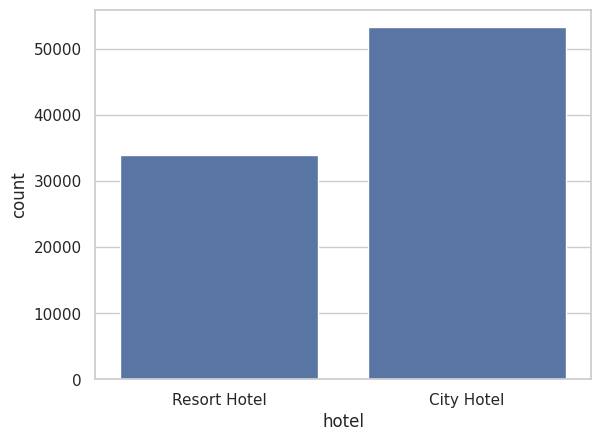

In [54]:
#hotel type
sns.countplot(data=df,
              x='hotel')

plt.show()






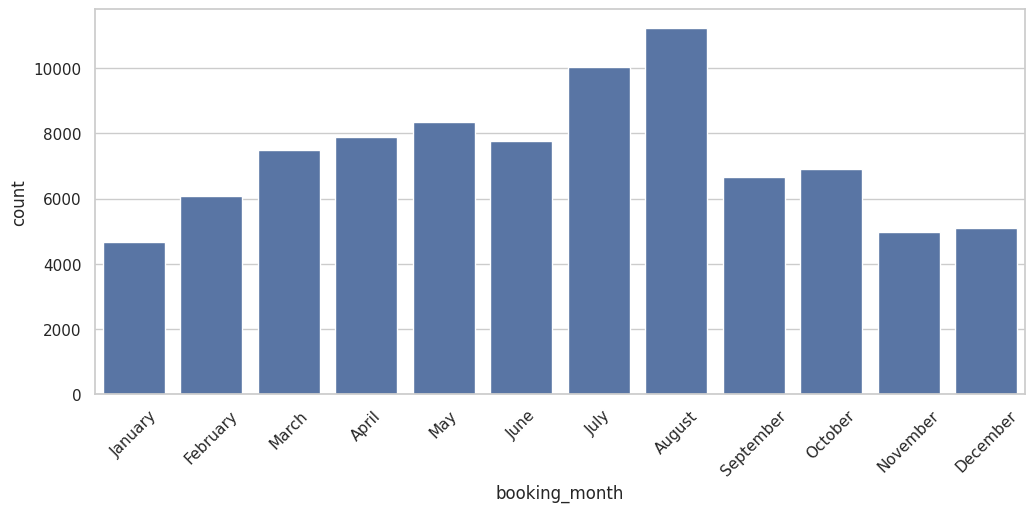

In [55]:
#monthly bookings
plt.figure(figsize=(12,5))

sns.countplot(data=df,
              x='booking_month',
              order=['January','February','March','April','May','June','July','August','September','October','November','December'])

plt.xticks(rotation=45)

plt.show()


<Axes: xlabel='country'>

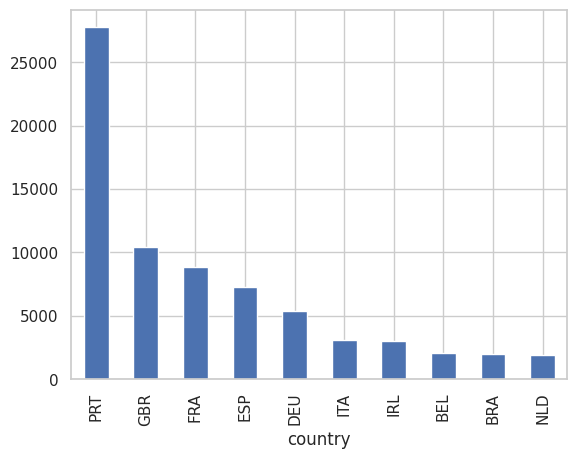

In [56]:
#top countries
df['country'].value_counts().head(10).plot(kind='bar')



<Axes: xlabel='hotel', ylabel='adr'>

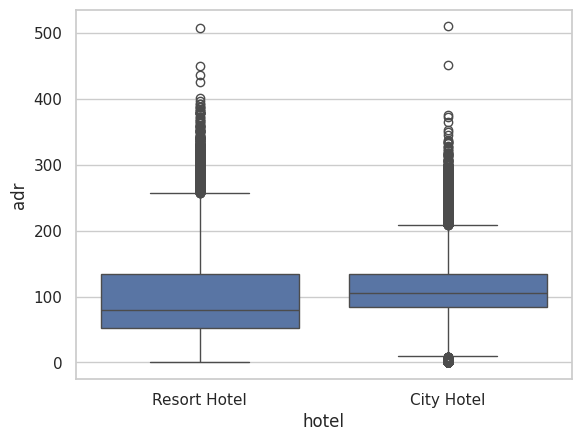

In [57]:
# adr by hotel
sns.boxplot(data=df,
            x='hotel',
            y='adr')



<Axes: xlabel='hotel', ylabel='count'>

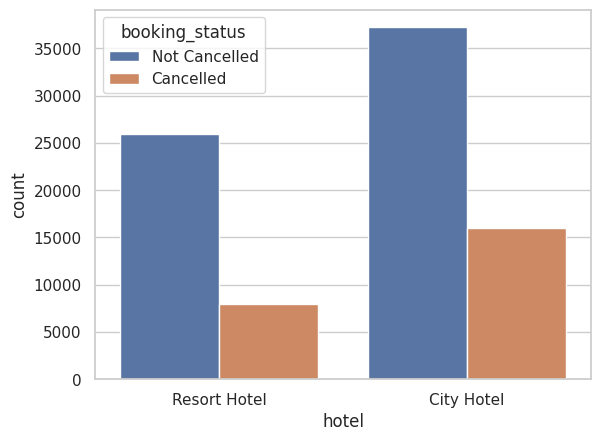

In [58]:
#hotel vs cancellation
sns.countplot(data=df,
              x='hotel',
              hue='booking_status')

<Axes: xlabel='hotel'>

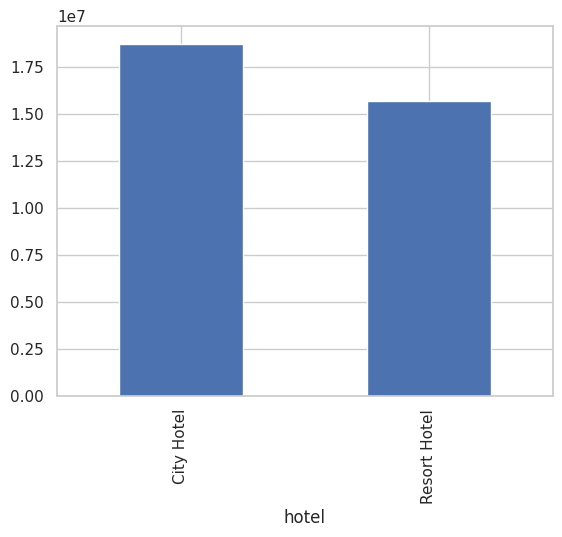

In [59]:
#revenue by hotel
df.groupby('hotel')['revenue'].sum().plot(kind='bar')

**BUSINESS INSIGHTS **

In [60]:
#TOTAL REVENUE
df['revenue'].sum()

np.float64(34442575.37)

In [61]:
#AVERAGE ADR
df['adr'].mean()

np.float64(106.48059386182219)

In [62]:
#CANCELLATION RATE
df['is_canceled'].mean()*100

np.float64(27.522020368841176)

In [63]:
#AVERAGE STAY
df['total_nights'].mean()

np.float64(3.62891090925773)

In [64]:
#AVERAGE GUEST
df['total_guests'].mean()

np.float64(2.0257707129094413)

In [65]:
#REVENUE BY HOTEL
df.groupby('hotel')['revenue'].sum()



,revenue
hotel,
City Hotel,18759375.36
Resort Hotel,15683200.01


In [66]:
#REVENUE BY COUNTRY
df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

,revenue
country,
PRT,9165854.43
GBR,4720787.01
FRA,3598061.87
ESP,2973939.80
DEU,2113113.24
IRL,1536940.05
ITA,1211894.46
BEL,888707.49
BRA,795122.03


In [70]:
!pip install pycountry

In [71]:
import pycountry

def country_name(code):
    try:
        return pycountry.countries.get(alpha_3=code).name
    except:
        return code

df['country'] = df['country'].apply(country_name)

In [72]:
df['country'].unique()[:20]

array(['Portugal', 'United Kingdom', 'United States', 'Spain', 'Ireland',
       'France', 'Romania', 'Norway', 'Oman', 'Argentina', 'Poland',
       'Germany', 'Belgium', 'Switzerland', 'CN', 'Greece', 'Italy',
       'Netherlands', 'Denmark', 'Russian Federation'], dtype=object)

In [73]:
df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

,revenue
country,
Portugal,9165854.43
United Kingdom,4720787.01
France,3598061.87
Spain,2973939.80
Germany,2113113.24
Ireland,1536940.05
Italy,1211894.46
Belgium,888707.49
Brazil,795122.03


In [74]:
invalid = df[~df['country'].isin([c.name for c in pycountry.countries])]

print("Unmatched countries:", invalid['country'].unique())

Unmatched countries: ['CN' 'TMP']


In [75]:
# Fix unmatched country codes
df['country'] = df['country'].replace({
    'CN': 'China',
    'TMP': 'Timor-Leste'
})

In [76]:
invalid = df[~df['country'].isin([c.name for c in pycountry.countries])]

print("Unmatched countries:", invalid['country'].unique())

Unmatched countries: []


In [77]:
df['country'].sort_values().unique()

array(['Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola',
       'Anguilla', 'Antarctica', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Benin',
       'Bolivia, Plurinational State of', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Cayman Islands',
       'Central African Republic', 'Chile', 'China', 'Colombia',
       'Comoros', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia',
       "Côte d'Ivoire", 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia',
       'Ethiopia', 'Faroe Islands', 'Fiji', 'Finland', 'France',
       'French Polynesia', 'French Southern Territories', 'Gabon',
       'Georgia', 'Germany', 'Ghana', 'Gibraltar', 'Greece', 'Guadeloupe',
       'Guatemala', 'Guernsey', 'Guinea-Bissau', 'Guyana',

In [78]:
df.to_csv("hotel_bookings_cleaned.csv", index=False)

from google.colab import files
files.download("hotel_bookings_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>